# HW4: Palmer Penguins — Summary Statistics & Plots

### Setup

- Use only `pandas`, `matplotlib`, and `seaborn`.
- Do your work in the cells provided; you may add extra cells.


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (Optional) nicer display for DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)


In [72]:
### Load the dataset
penguins = pd.read_csv("penguins.csv")

# Standardize column names (snake_case)
penguins.columns = [c.strip().lower().replace(' ', '_') for c in penguins.columns]

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Part 1) Data Vitals

Answer the following questions.

Your answer to each question must include some code that produces the result. You can, but you do not have to use a complete sentence to answer each question. Add cells as needed.

- a. What is the shape of the data?
- b. What are the Column names and data types of each column?
- c. How many values in each column are missing?
- d. How many penguins are there of each species? How many male and female penguins are there?

In [73]:
# a
print(penguins.shape)

(344, 8)


In [74]:
# b
print(penguins.columns)
print(penguins.dtypes)

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='str')
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
year                   int64
dtype: object


In [75]:
# c
print(penguins.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [76]:
# d
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [77]:
penguins['sex'].value_counts()

sex
male      168
female    165
Name: count, dtype: int64

### Part 2) Handle missing data

- a. Create a copy `penguins_clean` that **drops** rows with missing values in
   `['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex']`.  
- b. Report the new shape of `penguins_clean`.


In [78]:
# a
penguins_clean = penguins.dropna(subset=['bill_length_mm','bill_depth_mm','flipper_length_mm',
                                         'body_mass_g','sex']).copy()
# b
penguins_clean.shape

(333, 8)

### Part 3) Numeric summary statistics

- a. Compute the following **for each numeric column**: count, mean, std, min, 25%, 50%, 75%, max (hint: `.describe()`)
- b. Compute the mean and std for each numeric column for each `species`

In [79]:
# a
penguins_clean.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000,333.000,333.000,333.000,333.000
mean,43.993,17.165,200.967,4207.057,2008.042
std,5.469,1.969,14.016,805.216,0.813
min,32.100,13.100,172.000,2700.000,2007.000
25%,39.500,15.600,190.000,3550.000,2007.000
50%,44.500,17.300,197.000,4050.000,2008.000
75%,48.600,18.700,213.000,4775.000,2009.000
max,59.600,21.500,231.000,6300.000,2009.000


In [80]:
# b
penguins_clean.groupby(by = 'species').mean(numeric_only = True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
species,,,,,
Adelie,38.824,18.347,190.103,3706.164,2008.055
Chinstrap,48.834,18.421,195.824,3733.088,2007.971
Gentoo,47.568,14.997,217.235,5092.437,2008.067


In [81]:
penguins_clean.groupby(by = 'species').std(numeric_only = True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
species,,,,,
Adelie,2.663,1.219,6.522,458.620,0.812
Chinstrap,3.339,1.135,7.132,384.335,0.863
Gentoo,3.106,0.986,6.585,501.476,0.789


### Part 4) Two-way grouped summaries

a) For each **(species, sex)** combination, compute the **mean** and **count** of:
- `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

b) Which (species, sex) has the **largest average body_mass_g**? Show the row.



In [82]:
# a
species_sex_summary = penguins_clean.groupby(['species', 'sex'])[['bill_length_mm', 'bill_depth_mm', 
                                        'flipper_length_mm', 'body_mass_g']].agg(['mean', 'count'])
species_sex_summary

bill_length_mm       bill_depth_mm       flipper_length_mm  \
                           mean count          mean count              mean   
species   sex                                                                 
Adelie    female         37.258    73        17.622    73           187.795   
          male           40.390    73        19.073    73           192.411   
Chinstrap female         46.574    34        17.588    34           191.735   
          male           51.094    34        19.253    34           199.912   
Gentoo    female         45.564    58        14.238    58           212.707   
          male           49.474    61        15.718    61           221.541   

                       body_mass_g        
                 count        mean count  
species   sex                             
Adelie    female    73    3368.836    73  
          male      73    4043.493    73  
Chinstrap female    34    3527.206    34  
          male      34    3938.971    34  
Gentoo    female    58    4679.741    58  
          male      61    5484.836    61

In [83]:
# b
species_sex_summary.loc[[species_sex_summary[('body_mass_g', 'mean')].idxmax()]]

bill_length_mm       bill_depth_mm       flipper_length_mm        \
                       mean count          mean count              mean count   
species sex                                                                     
Gentoo  male         49.474    61        15.718    61           221.541    61   

             body_mass_g        
                    mean count  
species sex                     
Gentoo  male    5484.836    61

### Part 5) Correlations

- a. Compute the **correlation matrix** among numeric columns.  
- b. Compute the correlation matrix **within each species** (hint: groupby).  
- c. Find an example of Simpson's Paradox in the data. https://en.wikipedia.org/wiki/Simpson%27s_paradox  
        - An example Simpson's Paradox would be a pair of variables that have a positive correlation within subgroups, but when all the groups are combined, there is negative correlation (or vice-versa). 

In [84]:
# a
penguins_clean.corr(numeric_only = True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000,-0.229,0.653,0.589,0.033
bill_depth_mm,-0.229,1.000,-0.578,-0.472,-0.048
flipper_length_mm,0.653,-0.578,1.000,0.873,0.151
body_mass_g,0.589,-0.472,0.873,1.000,0.022
year,0.033,-0.048,0.151,0.022,1.000


In [85]:
# b
penguins_clean.groupby(by = 'species').corr(numeric_only = True)

bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                                         
Adelie    bill_length_mm              1.000          0.386              0.332   
          bill_depth_mm               0.386          1.000              0.311   
          flipper_length_mm           0.332          0.311              1.000   
          body_mass_g                 0.544          0.580              0.465   
          year                        0.011         -0.235              0.328   
Chinstrap bill_length_mm              1.000          0.654              0.472   
          bill_depth_mm               0.654          1.000              0.580   
          flipper_length_mm           0.472          0.580              1.000   
          body_mass_g                 0.514          0.604              0.642   
          year                        0.042         -0.059              0.346   
Gentoo    bill_length_mm              1.000          0.654              0.664   
          bill_depth_mm               0.654          1.000              0.711   
          flipper_length_mm           0.664          0.711              1.000   
          body_mass_g                 0.667          0.723              0.711   
          year                        0.205          0.243              0.201   

                             body_mass_g   year  
species                                          
Adelie    bill_length_mm           0.544  0.011  
          bill_depth_mm            0.580 -0.235  
          flipper_length_mm        0.465  0.328  
          body_mass_g              1.000 -0.046  
          year                    -0.046  1.000  
Chinstrap bill_length_mm           0.514  0.042  
          bill_depth_mm            0.604 -0.059  
          flipper_length_mm        0.642  0.346  
          body_mass_g              1.000  0.037  
          year                     0.037  1.000  
Gentoo    bill_length_mm           0.667  0.205  
          bill_depth_mm            0.723  0.243  
          flipper_length_mm        0.711  0.201  
          body_mass_g              1.000  0.052  
          year                     0.052  1.000

c) An example of Simpson's Paradox in this data is between bill depth and bill length. Within each species individually, bill depth and bill length have a positive correlation (0.386 for Adelie, 0.654 for Chinstrap, 0.654 for Gentoo), but within the entire data set with all the species combined, bill depth and bill length have a negative correlation (-0.229). This is likely because the body size of each pengiun species is a confounding variable that affects the bill depths and lengths, so when the points for each species are graphed altogether, it can lead to a negative trend.

## Plots

- Each figure must have a **title**, **axis labels**, and a **legend** (when appropriate).
- Use readable tick labels and sensible limits.
- Be sure each graphic is displayed.

### Part 6) Histograms of body mass by species

Create **separate** histograms of `body_mass_g` for each species (three panels).
    
- Use the same binning across panels so comparisons are fair.  
- Label axes clearly


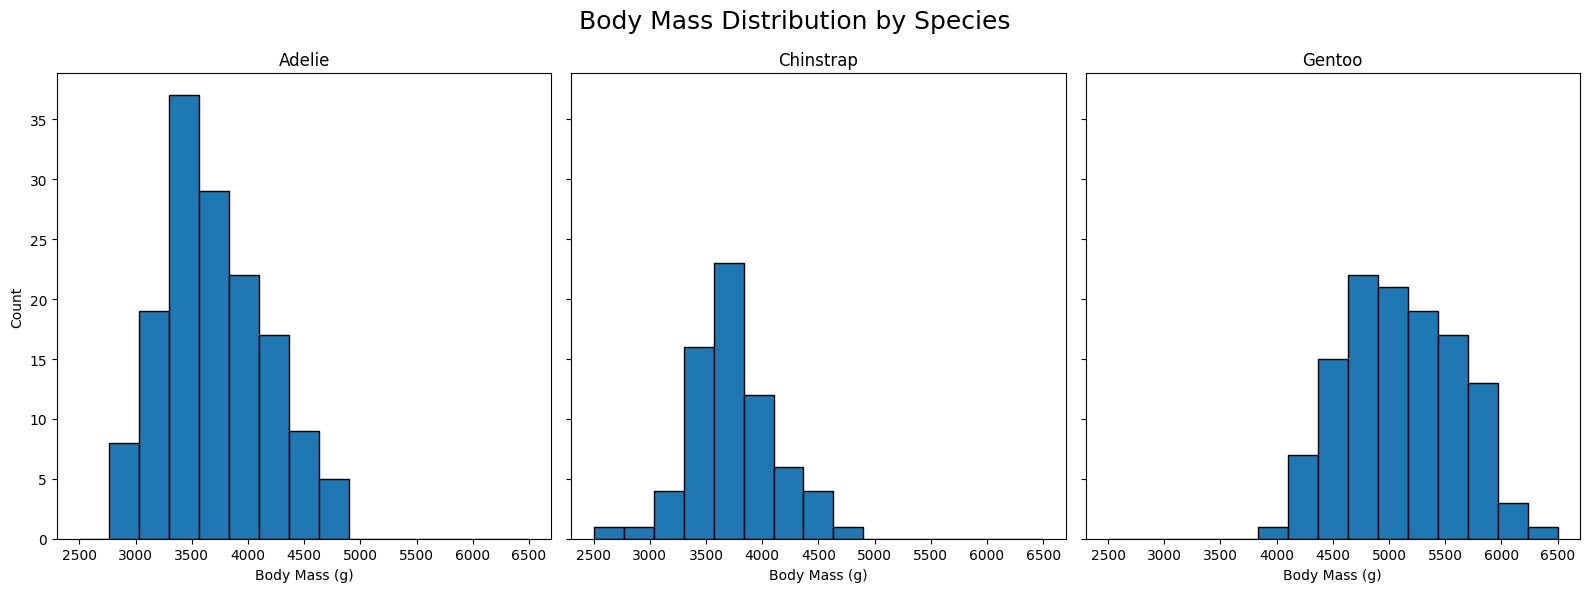

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey = True)

for i, species in enumerate(["Adelie", "Chinstrap", "Gentoo"]):
    data = penguins_clean[penguins_clean["species"] == species]["body_mass_g"]

    axes[i].hist(data, bins=15, range=(2500, 6500), edgecolor="black")
    axes[i].set_title(species)
    axes[i].set_xlabel("Body Mass (g)")

axes[0].set_ylabel("Count")

plt.suptitle("Body Mass Distribution by Species", fontsize=18)
plt.tight_layout()
plt.show()

### Part 7) Boxplots of flipper length

Make a **single figure** with boxplots of `flipper_length_mm` by **species**.  

Briefly compare the medians and spreads in 2–3 sentences in a markdown cell.

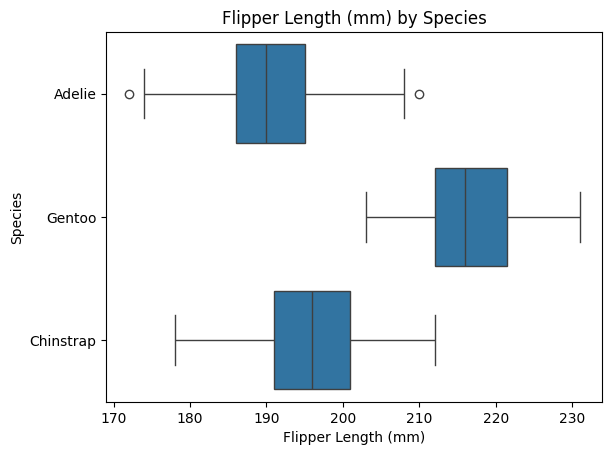

In [87]:
fig, ax = plt.subplots()
sns.boxplot(x="flipper_length_mm", y="species", data=penguins_clean, ax=ax)
ax.set_title("Flipper Length (mm) by Species")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Species")
plt.show()

The Gentoo species has the highest median flipper length (around 216mm), followed by the Chinstrap species (around 197mm), then the Adelie species with the lowest median flipper length (around 190mm). Gentoo and Chinstrap have very similar spreads looking at the IQRs, or middle 50% of data, indicated by the width of the blue boxes, while Adelie has the smallest spread (box is less wide) by IQR. It is a bit harder to distinguish with the ranges, but Gentoo appear to have the smallest range, then Chinstrap, and Adelie with the largest range due to the outliers.

### Part 8) Scatter: bill length vs bill depth

- Make a scatter plot of **bill_length_mm** (x) vs **bill_depth_mm** (y), colored by species.
- Add a simple **linear fit line** per species
- Include a legend 

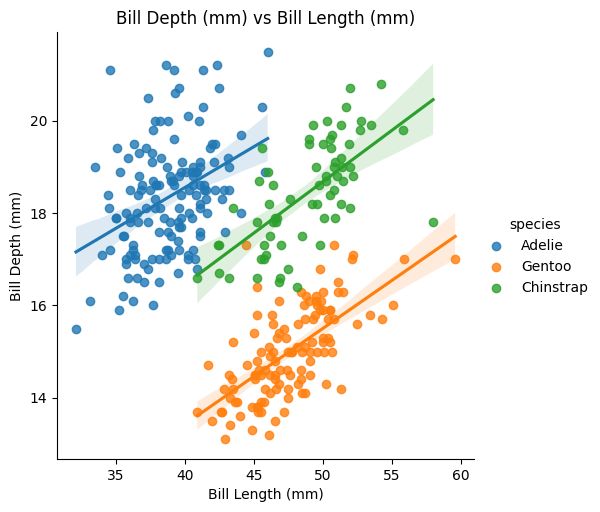

In [88]:
scatter = sns.lmplot(data=penguins_clean, x='bill_length_mm', y='bill_depth_mm', hue='species')
scatter.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
plt.title("Bill Depth (mm) vs Bill Length (mm)")
plt.show()

### Part 9) Stacked bars: sex proportions by species

Compute counts of `sex` within each `species`, convert to **proportions**, and make a **stacked bar chart**.  

- Bars should be species on the x‑axis with male/female proportions stacked to 1.0. 

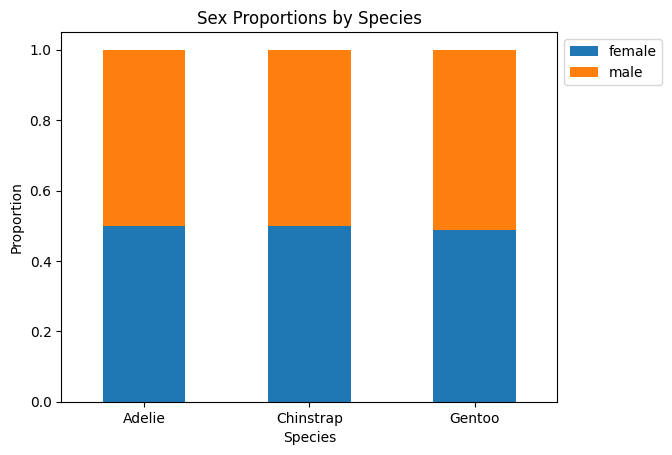

In [89]:
pd.crosstab(penguins_clean.species, penguins_clean.sex, normalize = 0).plot(kind = "bar", stacked = True)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("Species")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.title("Sex Proportions by Species")
plt.show()